<img src="https://i.imgur.com/HRhd2Y0.png" width="830">

## Import Brazilian E-commerce Public Dataset (Olist) form Kaggle

In [5]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

files = os.listdir(path)
print(files)

df_orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
df_products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
df_products_category = pd.read_csv(os.path.join(path, "product_category_name_translation.csv")) 
df_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
df_sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
df_customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
df_reviews = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
df_payments = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
df_locations = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))

Path to dataset files: /Users/kornkanoktripanpitak/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_dataset', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


## To create database, connect to SQLite (in-memory) and convert dataframe to sql table

In [6]:
import sqlite3

conn = sqlite3.connect(':memory:')

# Convert dataframe to sql table
df_orders.to_sql('orders', conn, index=False, if_exists='replace')
df_products.to_sql('products', conn, index=False, if_exists='replace')
df_products_category.to_sql('products_category', conn, index=False, if_exists='replace')
df_items.to_sql('items', conn, index=False, if_exists='replace')
df_sellers.to_sql('sellers', conn, index=False, if_exists='replace')
df_customers.to_sql('customers', conn, index=False, if_exists='replace')
df_reviews.to_sql('reviews', conn, index=False, if_exists='replace')
df_payments.to_sql('payments', conn, index=False, if_exists='replace')
df_locations.to_sql('locations', conn, index=False, if_exists='replace')

1000163

# SQL workflow for building your dashboard from the Olist schema (orders → items → products → customers)
SELECT → transformation → aggregation → export (CSV)

In [25]:
# Create view
conn.execute("DROP VIEW IF EXISTS fact_sales")

conn.execute("""
CREATE VIEW fact_sales AS
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    i.product_id,
    i.price,
    i.freight_value,
    (i.price + i.freight_value) AS revenue,
    pc.product_category_name_english,
    c.customer_city AS branch
FROM orders o
JOIN items i ON o.order_id = i.order_id
JOIN products p ON i.product_id = p.product_id
JOIN products_category pc ON p.product_category_name = pc.product_category_name
JOIN customers c ON o.customer_id = c.customer_id;
""")

# Read view
df1 = pd.read_sql("SELECT * FROM fact_sales ", conn)
display(df1)

# df1.to_csv('fact_sales.csv', index=False)

,order_id,order_purchase_timestamp,product_id,price,freight_value,revenue,product_category_name_english,branch
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,housewares,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,141.46,perfumery,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,179.12,auto,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,72.20,pet_shop,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,28.62,stationery,santo andre
...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,f1d4ce8c6dd66c47bbaa8c6781c2a923,174.90,20.10,195.00,baby,praia grande
111019,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,b80910977a37536adeddd63663f916ad,205.99,65.02,271.01,home_appliances_2,nova vicosa
111020,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,40.59,220.58,computers_accessories,japuiba
111021,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,40.59,220.58,computers_accessories,japuiba


In [30]:
# Calculate total revenue for all transactions occurring before 2019
query = """
SELECT 
    SUM(revenue) AS total_revenue
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12';
"""
df2 = pd.read_sql(query, conn)
df2

,total_revenue
0,15629890.34


In [31]:
# Total oders (distinct)
query = """
SELECT 
    COUNT(DISTINCT order_id) AS total_orders
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12';
"""
df3 = pd.read_sql(query, conn)
df3

,total_orders
0,97256


In [32]:
# Average order value
query = """
SELECT 
    SUM(revenue) * 1.0 / COUNT(DISTINCT order_id) AS avg_order_value
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12';
"""
df4 = pd.read_sql(query, conn)
df4

,avg_order_value
0,160.708752


In [33]:
# Orders by branch (city)
query = """
SELECT 
    branch,
    COUNT(DISTINCT order_id) AS n_orders
FROM fact_sales
WHERE order_purchase_timestamp <= '2018-12-31'
GROUP BY branch
ORDER BY n_orders DESC;
"""
df5 = pd.read_sql(query, conn)
df5

,branch,n_orders
0,sao paulo,15155
1,rio de janeiro,6724
2,belo horizonte,2701
3,brasilia,2086
4,curitiba,1495
...,...,...
4090,acucena,1
4091,acari,1
4092,acajutiba,1
4093,abdon batista,1


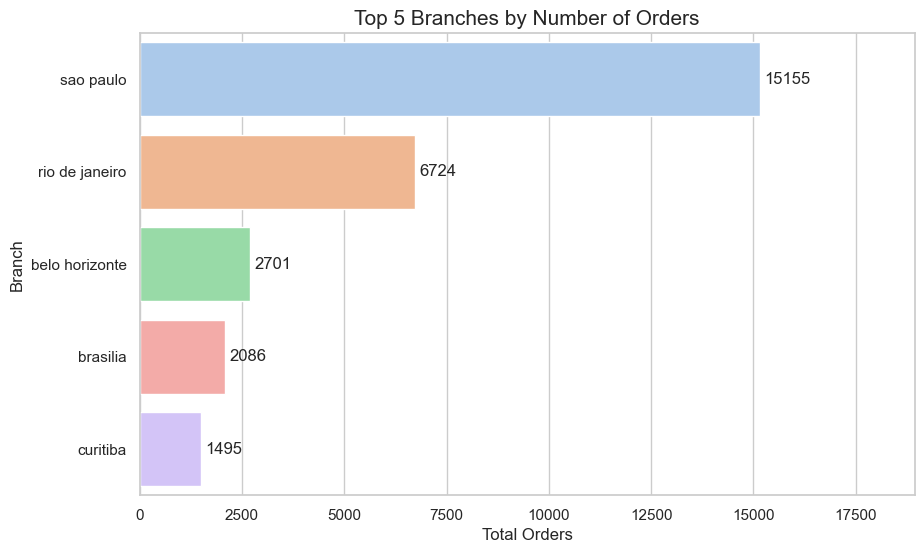

In [67]:
# Bar plot for df5

import seaborn as sns
import matplotlib.pyplot as plt

# Sort and take the top 5 for a clean visual
top5 = df5.nlargest(5, 'n_orders')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top5, 
    x='n_orders', 
    y='branch', 
    palette='pastel', 
    hue='branch', 
    legend=False
)

# Add the labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3) # padding=3 pushes the text slightly away from the bar end

plt.xlim(0, top5['n_orders'].max() * 1.25)
plt.title('Top 5 Branches by Number of Orders', fontsize=15)
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Branch', fontsize=12)

plt.show()

In [34]:
# Number of products per category
query = """
SELECT 
    product_category_name_english,
    COUNT(DISTINCT product_id) AS n_products
FROM fact_sales
GROUP BY product_category_name_english
ORDER BY n_products DESC;
"""
df6 = pd.read_sql(query, conn)
df6

,product_category_name_english,n_products
0,bed_bath_table,3029
1,sports_leisure,2867
2,furniture_decor,2657
3,health_beauty,2444
4,housewares,2335
...,...,...
66,tablets_printing_image,9
67,home_comfort_2,5
68,fashion_childrens_clothes,5
69,security_and_services,2


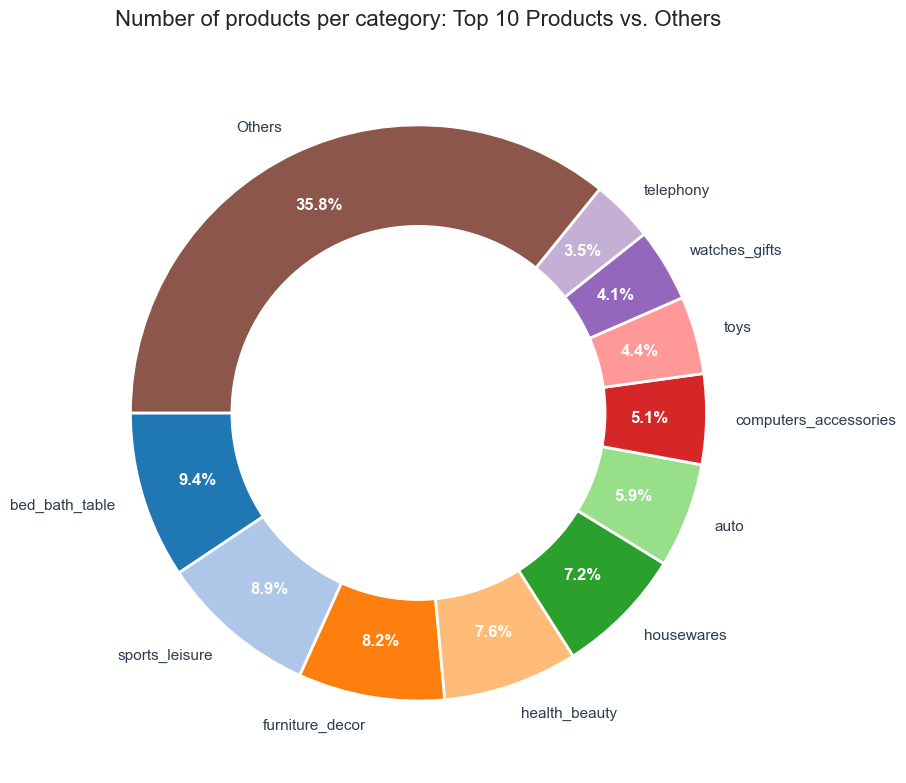

In [102]:
# Plot pie chart for df6
top_n = 10
top_df = df6.nlargest(top_n, 'n_products').copy()
others_sum = df6.sort_values('n_products', ascending=False).iloc[top_n:]['n_products'].sum()

# Create a clean DataFrame for the pie
pie_data = pd.concat([
    top_df, 
    pd.DataFrame({'product_category_name_english': ['Others'], 'n_products': [others_sum]})
])

# Setup the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
colors = sns.color_palette('tab20', n_colors=len(pie_data))

# 1. Capture 'labels' and 'texts' (the autopct values)
# patches is the first return, then the label objects, then the percent objects
patches, texts, autotexts = plt.pie(
    pie_data['n_products'], 
    labels=pie_data['product_category_name_english'], 
    autopct='%1.1f%%', 
    startangle=180, 
    colors=colors,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 2. Change the Category Label font color (the names outside)
for text in texts:
    text.set_color('#2c3e50')  # Example: Dark Grey/Blue
    text.set_fontsize(11)

# 3. Change the Percentage font color (the numbers inside)
for autotext in autotexts:
    autotext.set_color('white') # Example: Pure black for contrast
    autotext.set_weight('bold') # Make percentages pop
    
# Optional: Add a center circle to create a donut effect
centre_circle = plt.Circle((0,0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Number of products per category: Top 10 Products vs. Others', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [35]:
# Revenue by category
query = """
SELECT 
    product_category_name_english,
    SUM(revenue) AS total_revenue
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12'
GROUP BY product_category_name_english
ORDER BY total_revenue DESC;
"""
df7 = pd.read_sql(query, conn)
df7

,product_category_name_english,total_revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
...,...,...
66,flowers,1598.91
67,home_comfort_2,1170.58
68,cds_dvds_musicals,954.99
69,fashion_childrens_clothes,665.36


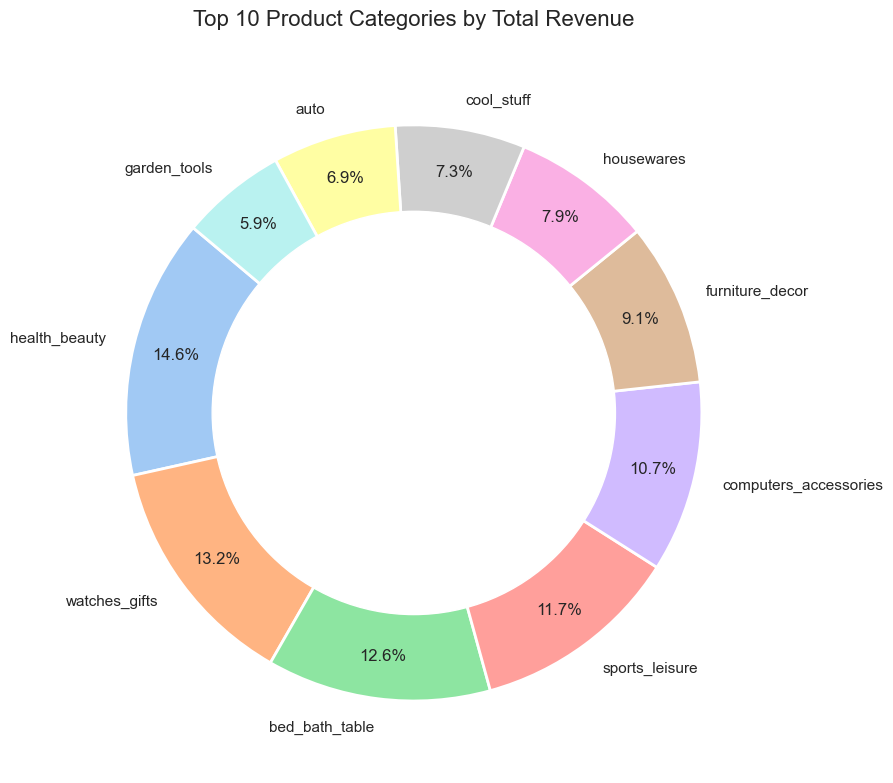

In [107]:
# Plot pie chart for df7
top10_rp = df7.nlargest(10, 'total_revenue')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')

ax = plt.pie(
    top10_rp['total_revenue'], 
    labels=top10_rp['product_category_name_english'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Top 10 Product Categories by Total Revenue', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [36]:
# Revenue by branch
query = """
SELECT 
    branch,
    SUM(revenue) AS total_revenue
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12'
GROUP BY branch
ORDER BY total_revenue DESC;
"""
df8 = pd.read_sql(query, conn)
df8

,branch,total_revenue
0,sao paulo,2137670.70
1,rio de janeiro,1140515.30
2,belo horizonte,410411.82
3,brasilia,349083.05
4,curitiba,242615.45
...,...,...
4090,santo antonio do rio abaixo,24.23
4091,tamboara,24.09
4092,jenipapo de minas,22.58
4093,polo petroquimico de triunfo,20.70


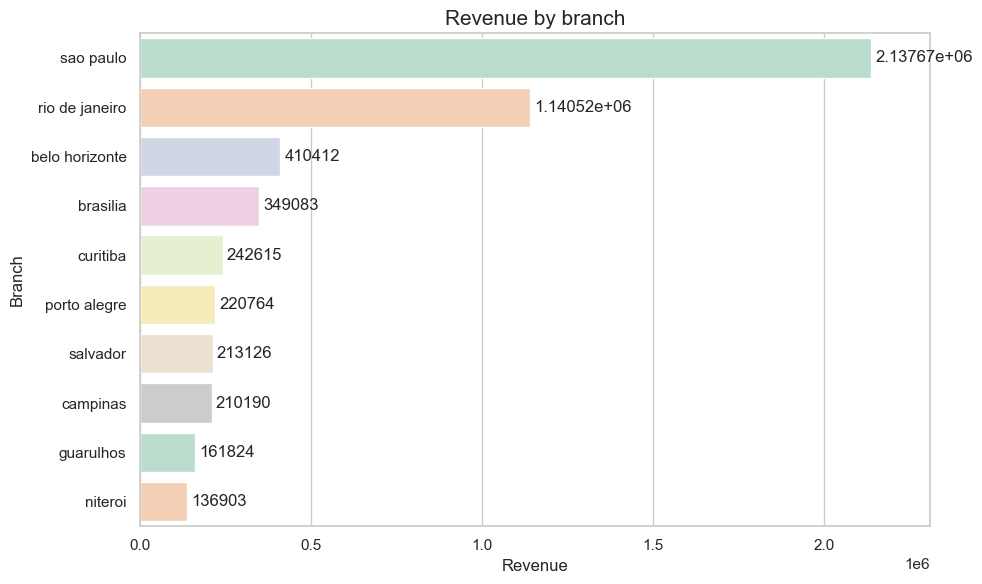

In [108]:
# Bar plot for df8
top10_rb = df8.nlargest(10, 'total_revenue')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_rb, 
    x='total_revenue', 
    y='branch', 
    palette='Pastel2', 
    hue='branch',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlim(0, top10_rb['total_revenue'].max() * 1.08)
plt.title('Revenue by branch', fontsize=15)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Branch')

plt.tight_layout()
plt.show()

In [109]:
# Top 5 products by quantity sold before year 2019
query = """
SELECT 
    product_category_name_english,
    COUNT(*) AS quantity_sold
FROM fact_sales
WHERE strftime('%Y-%m', order_purchase_timestamp) <= '2018-12'
GROUP BY product_category_name_english
ORDER BY quantity_sold DESC
LIMIT 5;
"""
df9 = pd.read_sql(query, conn)
df9

,product_category_name_english,quantity_sold
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827


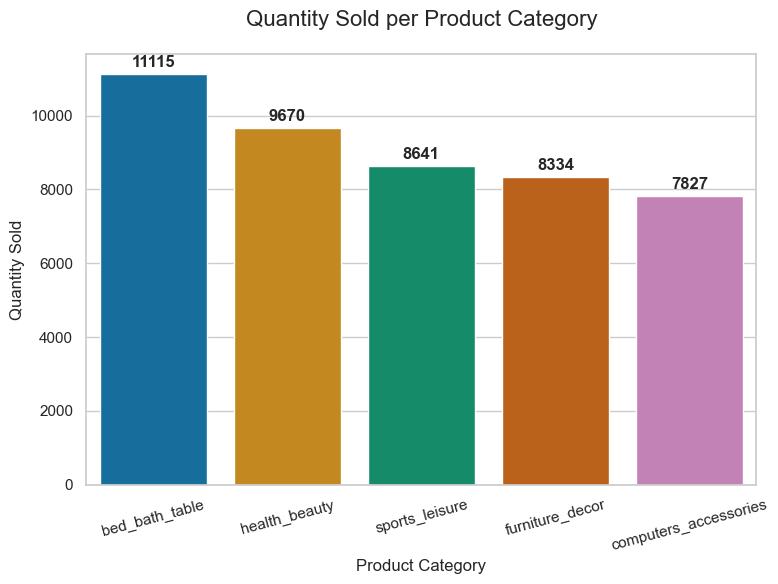

In [115]:
# Vertical bar plot for df9
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df9, 
    x='product_category_name_english', 
    y='quantity_sold', 
    palette='colorblind', 
    hue='product_category_name_english'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=12, fontweight='bold')
    
plt.title('Quantity Sold per Product Category', fontsize=16, pad=20)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [37]:
# Traffic Pattern: Orders by Hour
query = """
SELECT 
    strftime('%H', order_purchase_timestamp) AS hour,
    COUNT(DISTINCT order_id) AS n_orders
FROM fact_sales
GROUP BY hour
ORDER BY hour;
"""
df10 = pd.read_sql(query, conn)
df10

,hour,n_orders
0,00,2344
1,01,1142
2,02,495
3,03,266
4,04,203
5,05,182
6,06,492
7,07,1205
8,08,2912
9,09,4663


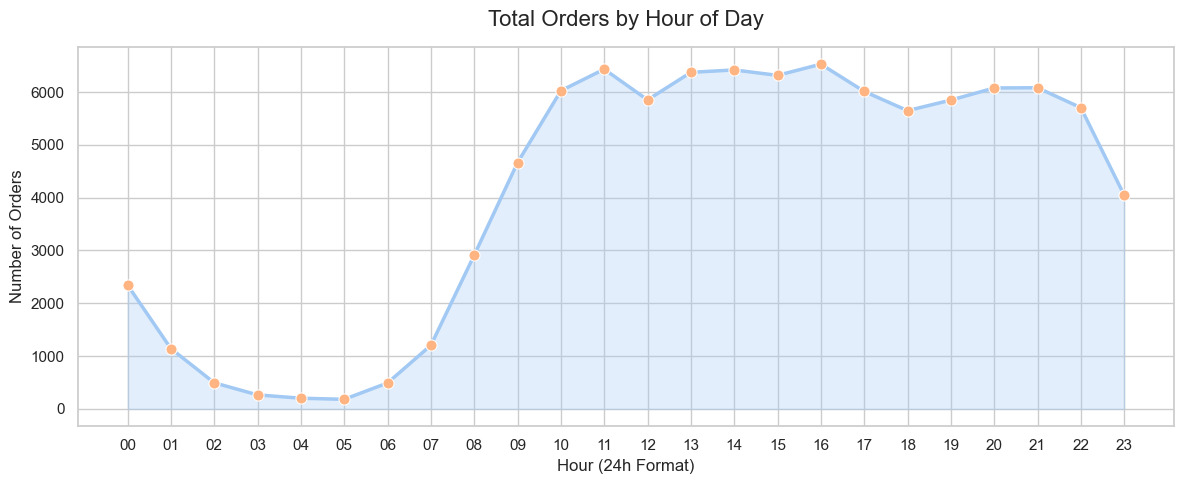

In [123]:
# Line plot for df10
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df10, 
    x='hour', 
    y='n_orders', 
    marker='o',         # Adds dots at each hour
    markersize=8,
    markerfacecolor=sns.color_palette("pastel")[1], # pastel orange
    linewidth=2.5, 
    color=sns.color_palette("pastel")[0] # use a specific color from the 'pastel' palette (i.e., the first blue)
)

plt.title('Total Orders by Hour of Day', fontsize=16, pad=15)
plt.xlabel('Hour (24h Format)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

# Ensure every hour (0-23) is visible on the X-axis
plt.xticks(range(0, 24))

# Fill the area under the line for a modern "Area Chart" look
plt.fill_between(df10['hour'], df10['n_orders'], color=sns.color_palette("pastel")[0], alpha=0.3)

plt.tight_layout()
plt.show()

In [130]:
# Traffic Pattern: Orders by Day of the Week
query = """
SELECT 
    CASE strftime('%w', order_purchase_timestamp)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS day_of_week,
    COUNT(DISTINCT order_id) AS n_orders
FROM fact_sales
GROUP BY day_of_week
ORDER BY strftime('%w', order_purchase_timestamp) ASC;
"""
# ORDER BY n_orders DESC

df11 = pd.read_sql(query, conn)
df11

,day_of_week,n_orders
0,Sunday,11710
1,Monday,15847
2,Tuesday,15607
3,Wednesday,15193
4,Thursday,14437
5,Friday,13812
6,Saturday,10650


In [ ]:
df1

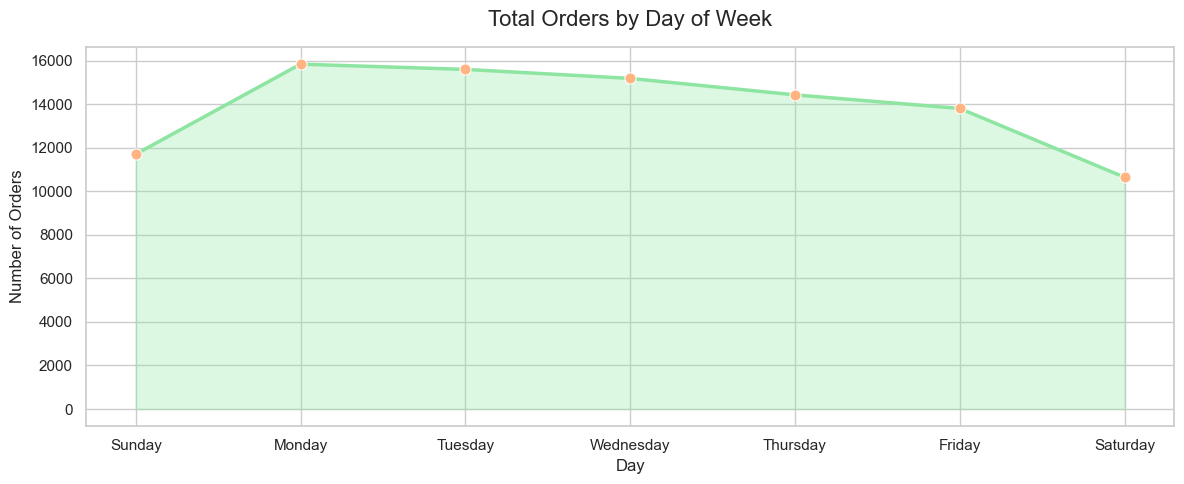

In [131]:
# Line plot for df11
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df11, 
    x='day_of_week', 
    y='n_orders', 
    marker='o',         # Adds dots at each hour
    markersize=8,
    markerfacecolor=sns.color_palette("pastel")[1], # pastel orange
    linewidth=2.5, 
    color=sns.color_palette("pastel")[2] # pastel green
)

plt.title('Total Orders by Day of Week', fontsize=16, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

# Fill the area under the line for a modern "Area Chart" look
plt.fill_between(df11['day_of_week'], df11['n_orders'], color=sns.color_palette("pastel")[2], alpha=0.3)

plt.tight_layout()
plt.show()

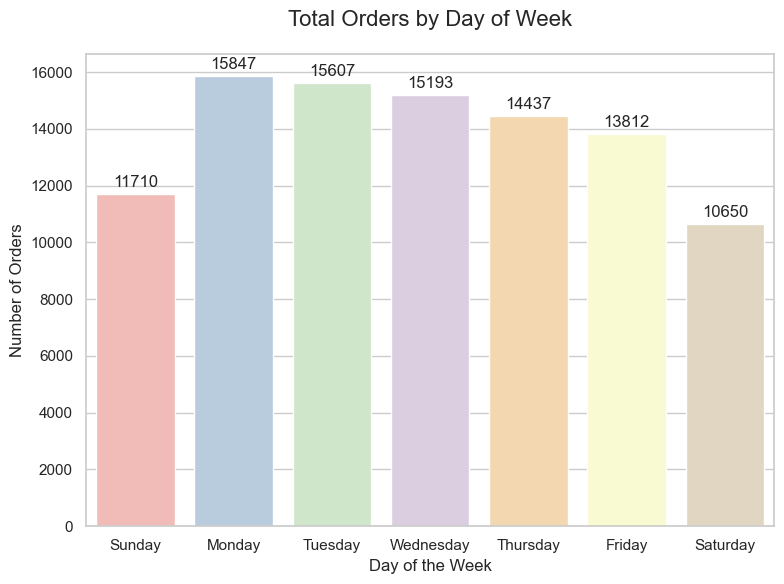

In [135]:
# Vertical bar plot for df11
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df11, 
    x='day_of_week', 
    y='n_orders', 
    palette='Pastel1', 
    hue='day_of_week'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=12) # fontweight='bold'
    
plt.title('Total Orders by Day of Week', fontsize=16, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()